In [31]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing Data

In [32]:
# load the dataset
crop = pd.read_csv("datasets/Crop_recommendation.csv")
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,21,82,7,203,rice
1,85,58,41,22,80,7,227,rice
2,60,55,44,23,82,8,264,rice
3,74,35,40,27,80,7,243,rice
4,78,42,42,20,82,8,263,rice


In [33]:
# Check the shape of the dataset
crop.shape

(2200, 8)

In [34]:
# Check the basic information of the dataset
crop.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   N            2200 non-null   int64 
 1   P            2200 non-null   int64 
 2   K            2200 non-null   int64 
 3   temperature  2200 non-null   int64 
 4   humidity     2200 non-null   int64 
 5   ph           2200 non-null   int64 
 6   rainfall     2200 non-null   int64 
 7   label        2200 non-null   object
dtypes: int64(7), object(1)
memory usage: 137.6+ KB


In [35]:
# Check the missing values in the dataset
crop.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [36]:
# Check the duplicated values in the dataset
crop.duplicated().sum()

np.int64(0)

In [37]:
# Check the basic statistics of the dataset
crop.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.663182,71.540455,6.537273,103.517727
std,36.917334,32.985883,50.647931,5.077365,22.284167,0.799313,54.955310
min,0.000000,5.000000,5.000000,9.000000,14.000000,4.000000,20.000000
25%,21.000000,28.000000,20.000000,23.000000,60.000000,6.000000,65.000000
50%,37.000000,51.000000,32.000000,26.000000,81.000000,6.000000,95.000000
75%,84.250000,68.000000,49.000000,29.000000,90.000000,7.000000,124.000000
max,140.000000,145.000000,205.000000,44.000000,100.000000,10.000000,299.000000


## Exploring Data

In [38]:
# Check the target distribution
crop['label'].value_counts()

label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [39]:
features = crop.columns.to_list()
features.remove('label')
print(features)

['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']


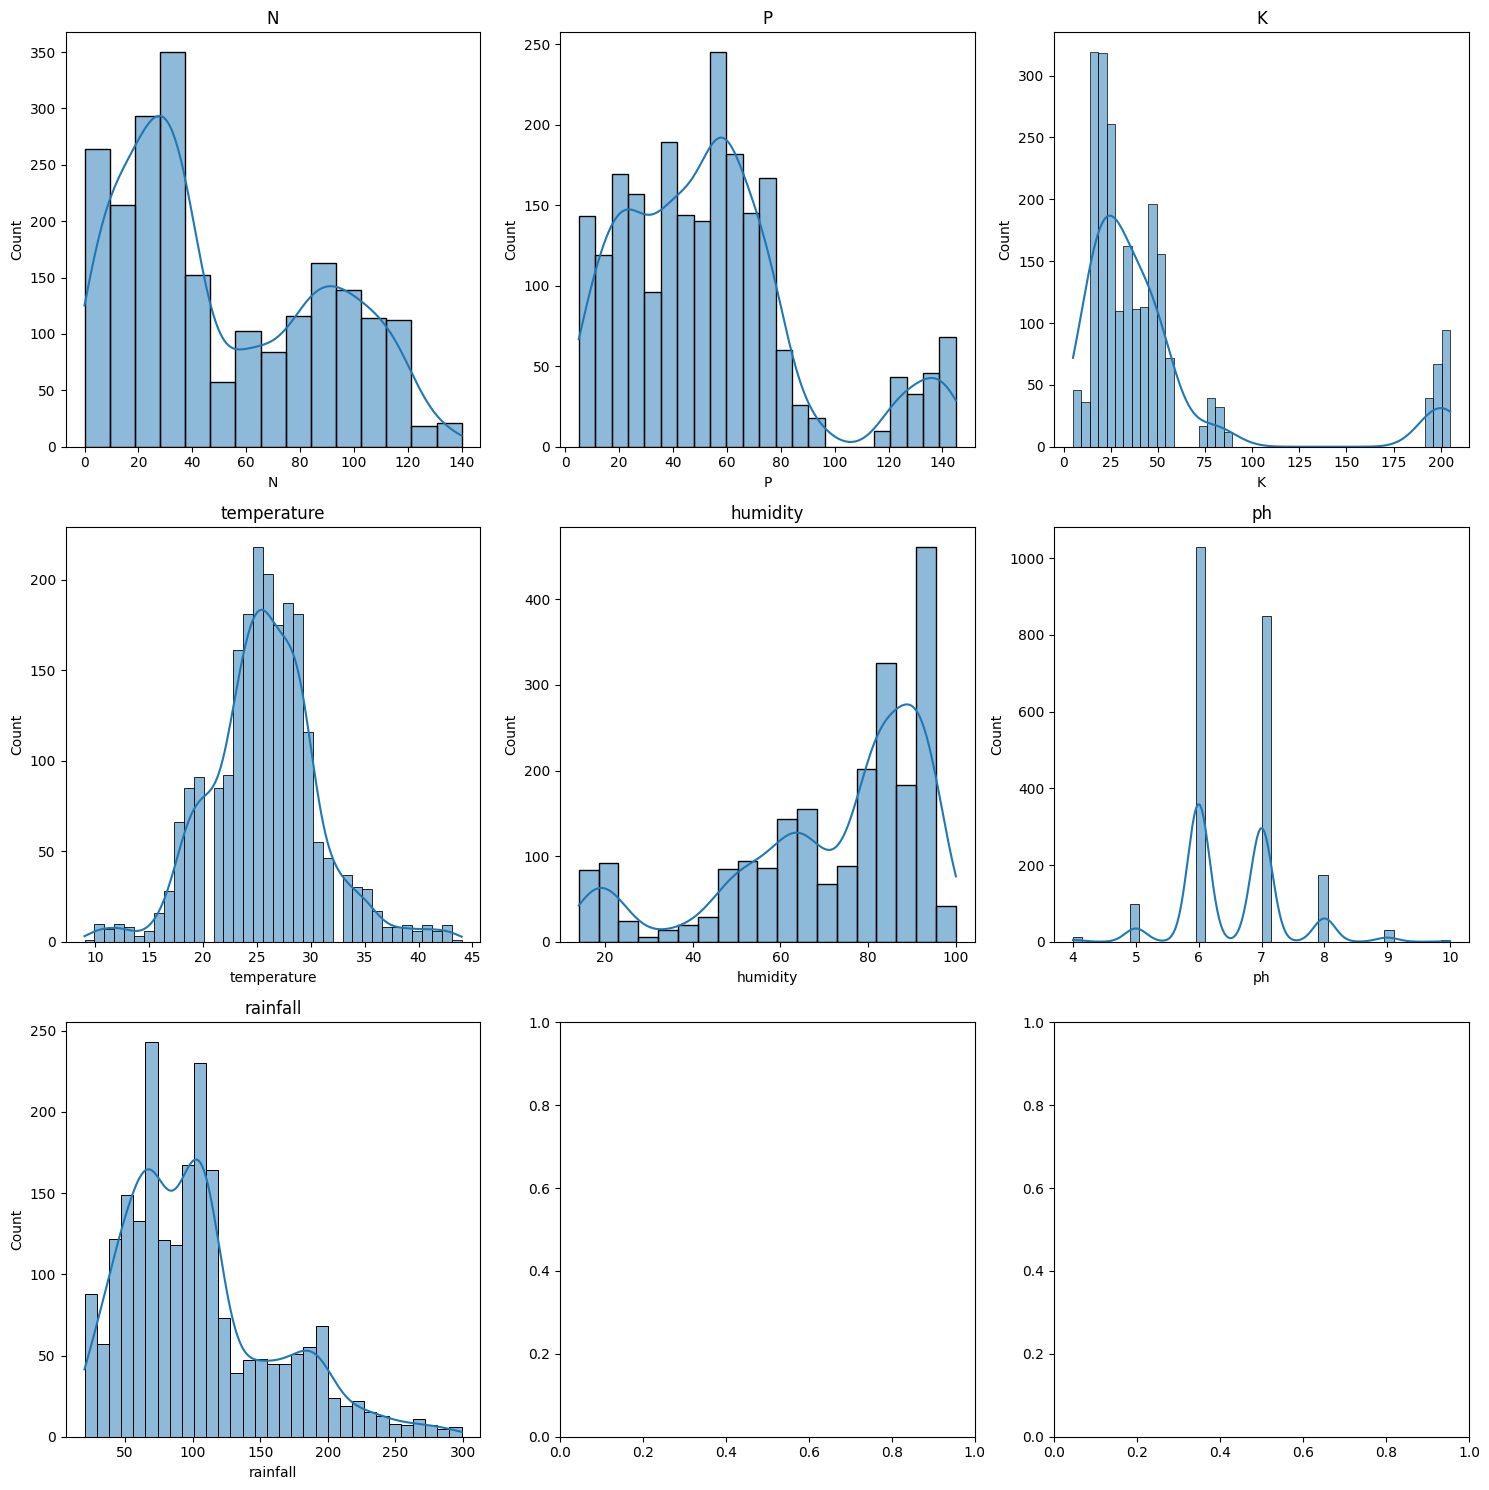

In [40]:
# visualize the distribution of each feature
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for i, subplot in zip(features, ax.flatten()):
    sns.histplot(crop[i], ax=subplot, kde=True)
    subplot.set_title(i)
plt.tight_layout()
plt.show()


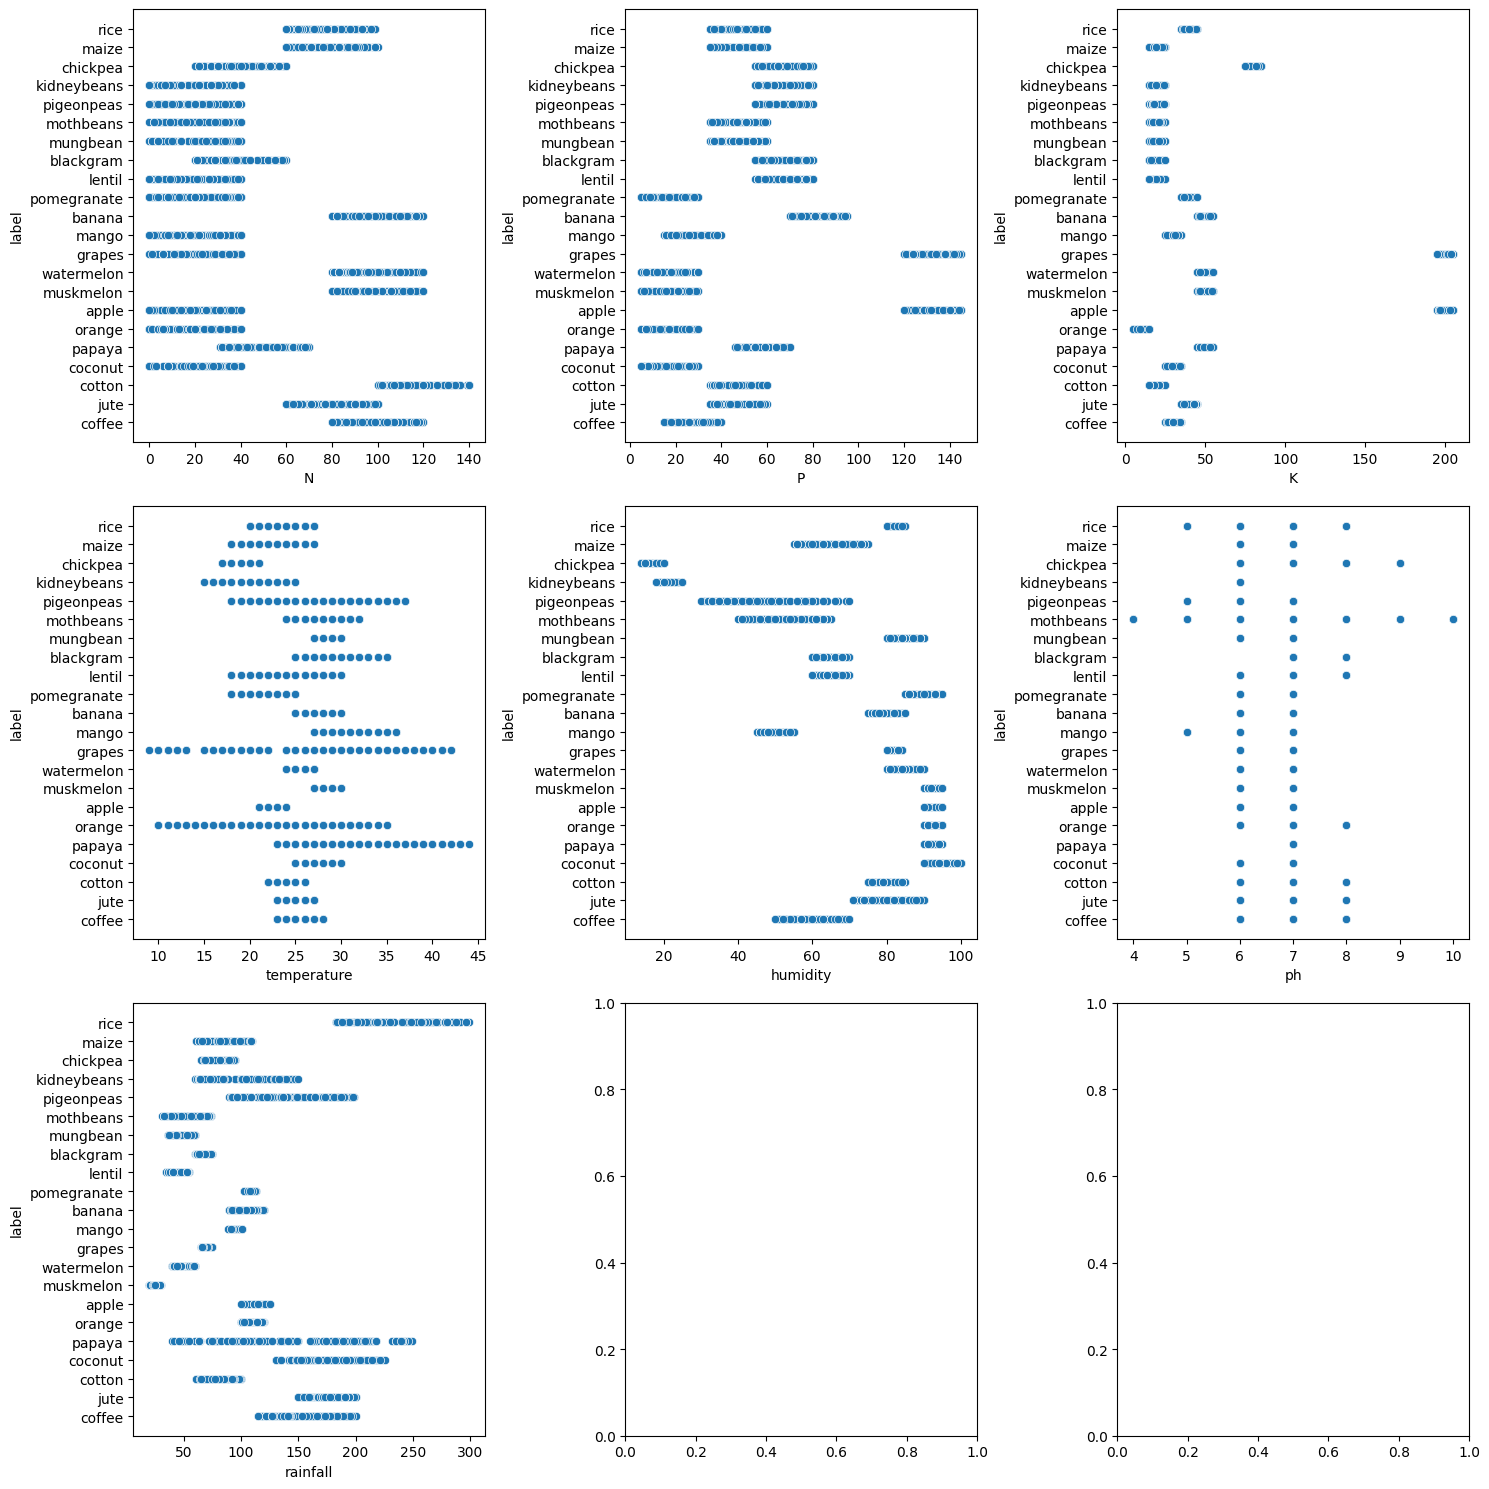

In [41]:
# plot scatter plot of each feature against the target
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for i, subplot in zip(features, ax.flatten()):
    sns.scatterplot(x=i, y='label', data=crop, ax=subplot)
plt.tight_layout()
plt.show()

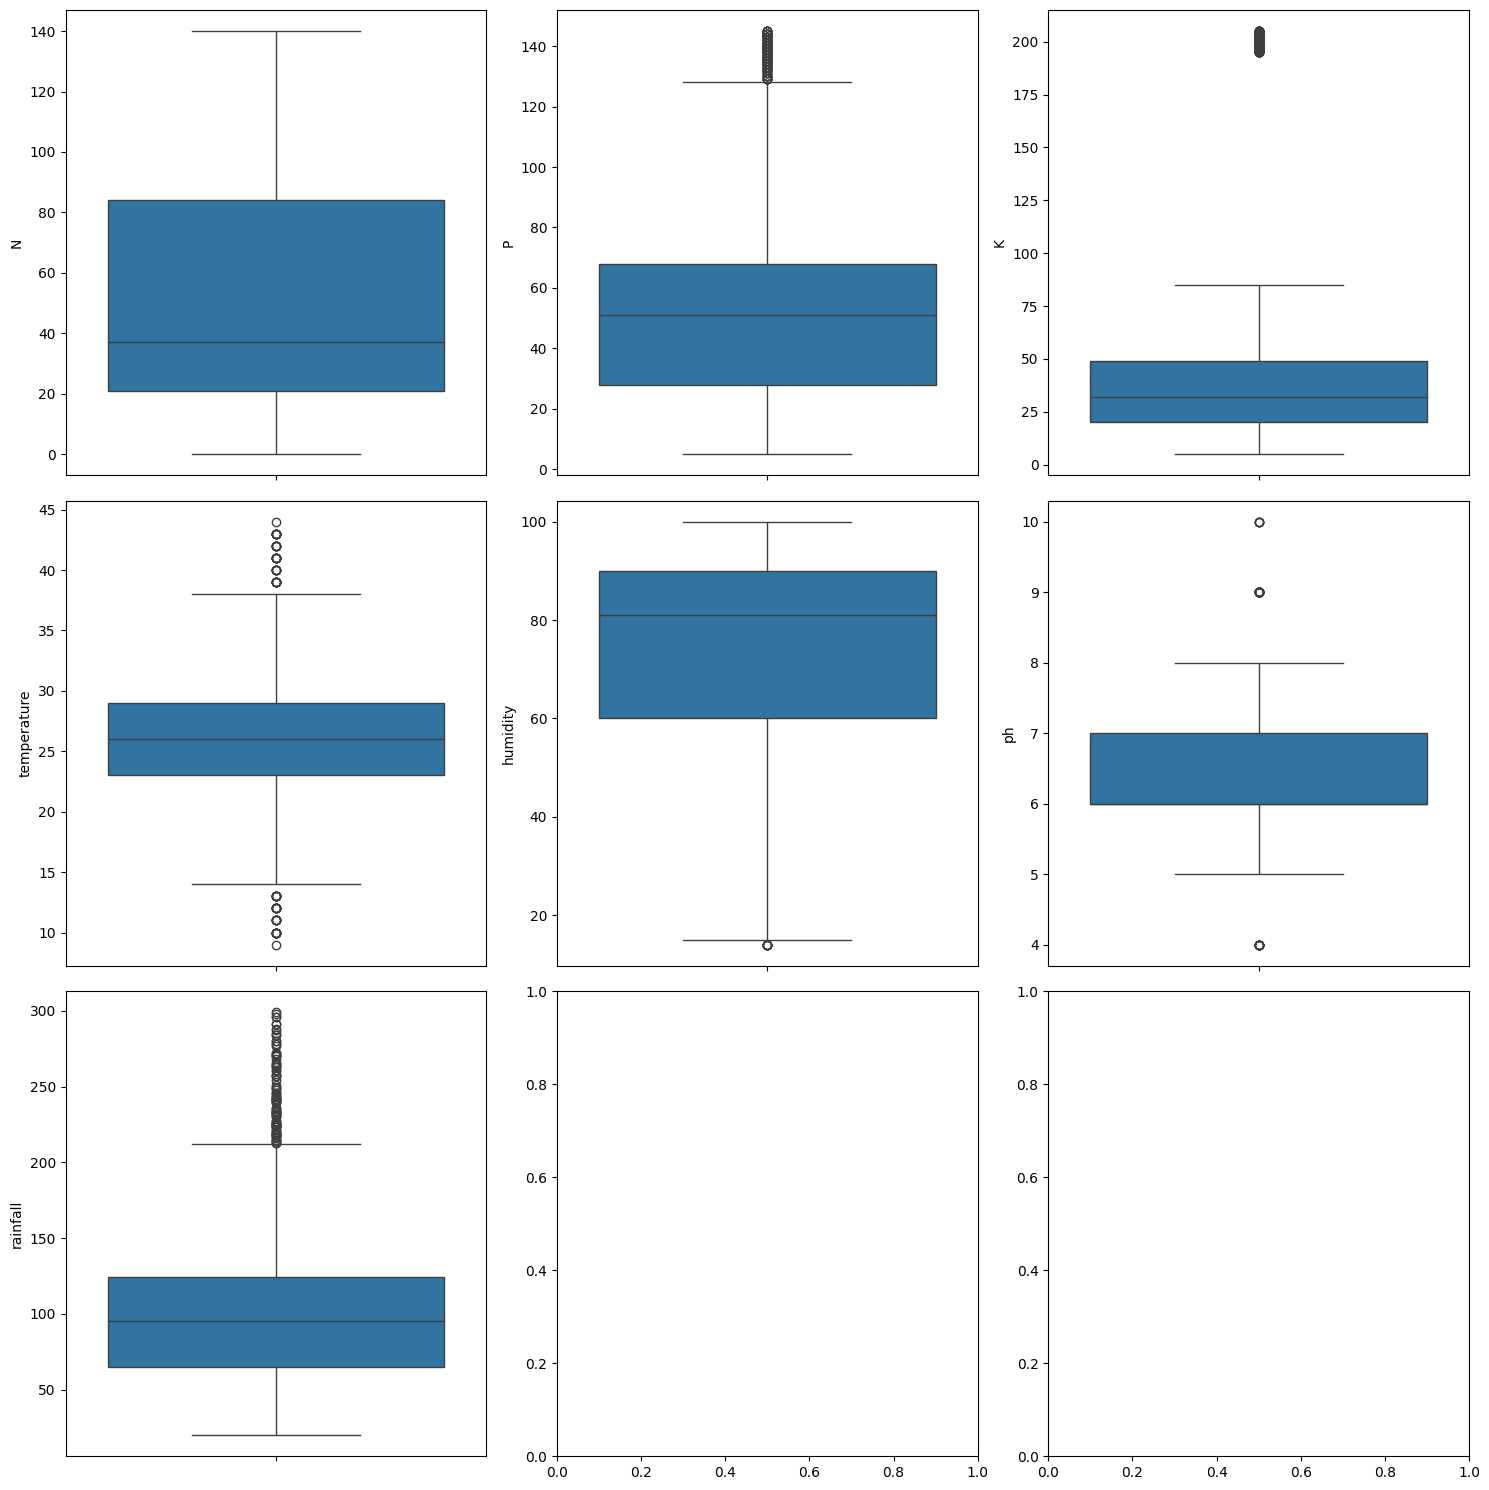

In [42]:
# create box plot for each feature to check for outliers
fig, ax = plt.subplots(3, 3, figsize=(15, 15))
for i, subplot in zip(features, ax.flatten()):
    sns.boxplot(crop[i], ax=subplot)
plt.tight_layout()
plt.show()

In [43]:
# check the correlation of the features
numeric_columns = crop.select_dtypes(include=[np.number])
corr = numeric_columns.corr()
corr

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.231460,-0.140512,0.026546,0.190560,0.064152,0.059081
P,-0.231460,1.000000,0.736232,-0.128793,-0.118096,-0.113468,-0.063819
K,-0.140512,0.736232,1.000000,-0.160419,0.191257,-0.165296,-0.053455
temperature,0.026546,-0.128793,-0.160419,1.000000,0.204652,-0.020268,-0.029723
humidity,0.190560,-0.118096,0.191257,0.204652,1.000000,-0.037372,0.094090
ph,0.064152,-0.113468,-0.165296,-0.020268,-0.037372,1.000000,-0.102914
rainfall,0.059081,-0.063819,-0.053455,-0.029723,0.094090,-0.102914,1.000000


<Axes: >

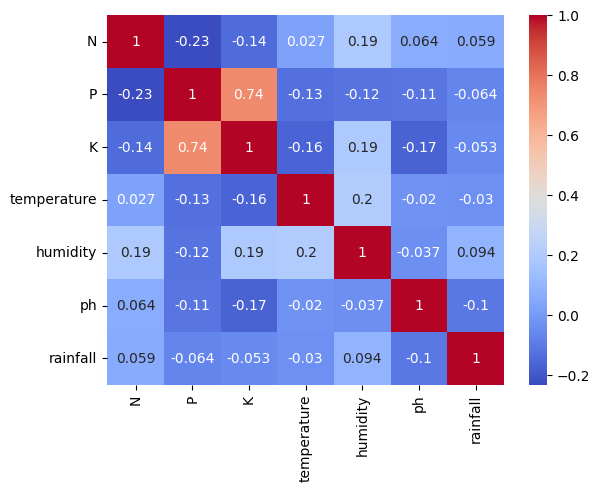

In [44]:
# Visualize the correlation matrix
import seaborn as sns
sns.heatmap(corr,annot=True,cbar=True,cmap='coolwarm')

## Encoding

In [45]:
crop_dict = {
'rice':1,
'maize':2,
'jute':3,
'cotton':4,
'coconut':5,
'papaya':6,
'orange':7,
'apple':8,
'muskmelon':9,
'watermelon':10,
'grapes':11,
'mango':12,
'banana':13,
'pomegranate':14,
'lentil':15,
'blackgram':16,
'mungbean':17,
'mothbeans':18,
'pigeonpeas':19,
'kidneybeans':20,
'chickpea':21,
'coffee': 22,
}

In [46]:
crop['crop_no'] = crop['label'].map(crop_dict)

In [47]:
crop.head()

,N,P,K,temperature,humidity,ph,rainfall,label,crop_no
0,90,42,43,21,82,7,203,rice,1
1,85,58,41,22,80,7,227,rice,1
2,60,55,44,23,82,8,264,rice,1
3,74,35,40,27,80,7,243,rice,1
4,78,42,42,20,82,8,263,rice,1


In [48]:
crop['crop_no'].value_counts()

crop_no
1     100
2     100
21    100
20    100
19    100
18    100
17    100
16    100
15    100
14    100
13    100
12    100
11    100
10    100
9     100
8     100
7     100
6     100
5     100
4     100
3     100
22    100
Name: count, dtype: int64

In [49]:
crop.drop('label',axis=1,inplace=True)
crop.tail()

,N,P,K,temperature,humidity,ph,rainfall,crop_no
2195,107,34,32,27,66,7,178,22
2196,99,15,27,27,57,6,128,22
2197,118,33,30,24,67,6,173,22
2198,117,32,34,26,52,7,127,22
2199,104,18,30,24,60,7,141,22


## Train Test Spilt

In [50]:
x = crop.drop('crop_no',axis=1)
y = crop['crop_no']

print(f"The shape of x is : {x.shape}")
print(f"The shape of y is : {y.shape}")

The shape of x is : (2200, 7)
The shape of y is : (2200,)


In [51]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split( x, y, test_size=0.2, random_state=42)

In [52]:
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (1760, 7)
Shape of y_train: (1760,)
Shape of x_test: (440, 7)
Shape of y_test: (440,)


### Scaling

In [53]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

## Training Models

In [54]:
# Let's Train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


In [55]:
# intialize the DecisionTree Classifier
DT = DecisionTreeClassifier()
# Train the model
DT.fit(x_train,y_train)

DecisionTreeClassifier()

In [56]:
# evaluate the model on test dataset
y_pred = DT.predict(x_test)
print(f"Accuracy score of Decision Tree Classifier is: {accuracy_score(y_test,y_pred)}")

Accuracy score of Decision Tree Classifier is: 0.9886363636363636


In [57]:
# evaluate the model on train dataset
y_pred_train = DT.predict(x_train)
print(f"Accuracy score of Decision Tree Classifier is: {accuracy_score(y_train,y_pred_train)}")

Accuracy score of Decision Tree Classifier is: 1.0


## Predictive System

In [58]:
def crop_recommend(N,P,K,temperature,humidity,ph,rainfall):
    features = np.array([[N,P,K,temperature,humidity,ph,rainfall]])
    transformed_features = sc.transform(features)
    prediction = DT.predict(transformed_features).reshape(1,-1)
    crop_dict = {1: "Rice", 2: "Maize", 3: "Jute", 4: "Cotton", 5: "Coconut", 6: "Papaya", 7: "Orange",
                 8: "Apple", 9: "Muskmelon", 10: "Watermelon", 11: "Grapes", 12: "Mango", 13: "Banana",
                 14: "Pomegranate", 15: "Lentil", 16: "Blackgram", 17: "Mungbean", 18: "Mothbeans",
                 19: "Pigeonpeas", 20: "Kidneybeans", 21: "Chickpea", 22: "Coffee"}
    crop = [crop_dict[i] for i in prediction[0]]

    
    return f"{crop} is a best crop to be cultivated " 

In [59]:
# Predicting the crop for the given environment
N = 90
P = 42
K = 43
temperature = 20
humidity = 82
ph = 6.1
rainfall = 202

crop_recommend(N,P,K,temperature,humidity,ph,rainfall)

c:\Users\bhawa\miniconda3\envs\dataScience\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


"['Rice'] is a best crop to be cultivated "

In [61]:
# Save the model
import pickle
pickle.dump(DT, open('crop_model.sav', 'wb'))

# Save the scaler
pickle.dump(sc, open('crop_scaler.sav', 'wb'))

#### Use a Trained saved model for new predictions

In [63]:
# load the saved model and predict the crop
DT = pickle.load(open('crop_model.sav', 'rb'))

# load the saved scaler
sc = pickle.load(open('crop_scaler.sav', 'rb'))

In [64]:
# Predicting the crop for the given environment
N = 90
P = 42
K = 43
temperature = 20
humidity = 82
ph = 6.1
rainfall = 202

crop_recommend(N,P,K,temperature,humidity,ph,rainfall)

c:\Users\bhawa\miniconda3\envs\dataScience\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


"['Rice'] is a best crop to be cultivated "